# DCGAN vs WGAN-GP — Tackling Mode Collapse
**Platform**: Kaggle | **GPU**: T4 x2 | **Dataset**: Anime Faces 64×64

In [23]:
import os
import pickle
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.autograd as autograd
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.utils import make_grid, save_image
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image
import gc

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f'  GPU {i}: {torch.cuda.get_device_name(i)}')

# Create output directories
os.makedirs('outputs/dcgan', exist_ok=True)
os.makedirs('outputs/wgan', exist_ok=True)
os.makedirs('checkpoints', exist_ok=True)

Device: cuda
  GPU 0: Tesla T4
  GPU 1: Tesla T4


In [24]:
# Image and model
IMAGE_SIZE = 64
NC = 3          # channels
NZ = 100        # latent vector size
NGF = 64        # generator features
NDF = 64        # discriminator/critic features

# Training
BATCH_SIZE = 32      # Safe for T4 (64 may cause OOM)
LR = 0.0002
BETAS = (0.5, 0.999)
NUM_EPOCHS_DCGAN = 10
NUM_EPOCHS_WGAN = 10

# WGAN-GP specific
LAMBDA_GP = 10
CRITIC_ITERS = 5
SAVE_EVERY = 5

print(f"Batch size: {BATCH_SIZE}, Image size: {IMAGE_SIZE}")

Batch size: 32, Image size: 64


In [25]:
def find_image_root():
    valid_exts = {'.png', '.jpg', '.jpeg', '.webp', '.bmp'}
    preferred = ['/kaggle/input/anime-faces', '/kaggle/input/pokemon-sprites']
    for base in preferred:
        if os.path.exists(base):
            for root, _, files in os.walk(base):
                if any(f.lower().endswith(tuple(valid_exts)) for f in files):
                    print(f"Found images in: {root}")
                    return root
    for root, _, files in os.walk('/kaggle/input'):
        if sum(1 for f in files if f.lower().endswith(tuple(valid_exts))) > 100:
            print(f"Found images in: {root}")
            return root
    raise FileNotFoundError("No dataset found. Add Anime Faces or Pokemon Sprites.")

DATA_DIR = find_image_root()

class ImageDataset(Dataset):
    def __init__(self, root, transform=None, max_samples=15000):
        self.transform = transform
        self.files = []
        for dirpath, _, fnames in os.walk(root):
            for f in fnames:
                if f.lower().endswith(('.png','.jpg','.jpeg','.webp')):
                    self.files.append(os.path.join(dirpath, f))
        if max_samples and len(self.files) > max_samples:
            self.files = random.sample(self.files, max_samples)
        print(f"Loaded {len(self.files)} images")
    def __len__(self): return len(self.files)
    def __getitem__(self, idx):
        img = Image.open(self.files[idx]).convert('RGB')
        if self.transform: img = self.transform(img)
        return img

transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)  # -> [-1,1]
])

dataset = ImageDataset(DATA_DIR, transform=transform, max_samples=15000)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True,
                        num_workers=0, pin_memory=True, drop_last=True)
print(f"Batches per epoch: {len(dataloader)}")

Found images in: /kaggle/input/datasets/soumikrakshit/anime-faces/data
Loaded 15000 images
Batches per epoch: 468


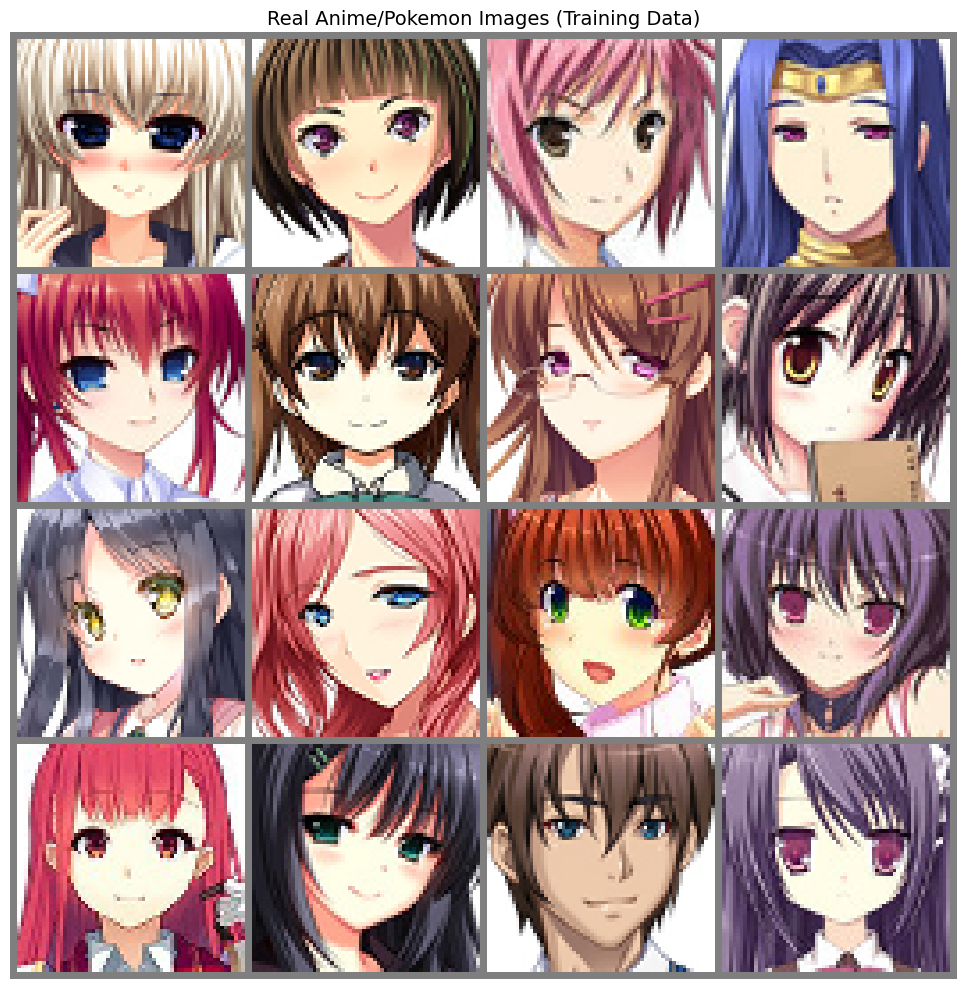

In [28]:
# ========== CELL 3.5: Show Real Training Images ==========
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

# Get one batch
data_iter = iter(dataloader)
real_batch = next(data_iter)

# Denormalize from [-1,1] to [0,1]
def denorm(img):
    return (img + 1) / 2

# Show 16 images
grid = make_grid(real_batch[:16], nrow=4, normalize=False)
grid = denorm(grid).cpu().numpy().transpose(1,2,0)

plt.figure(figsize=(10,10))
plt.imshow(grid)
plt.title("Real Anime/Pokemon Images (Training Data)", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.savefig('outputs/real_samples.png', dpi=100)
plt.show()


In [26]:
def weights_init(m):
    classname = m.__class__.__name__
    if 'Conv' in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

class DCGANGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(NZ, NGF*8, 4,1,0,bias=False), nn.BatchNorm2d(NGF*8), nn.ReLU(True),
            nn.ConvTranspose2d(NGF*8, NGF*4, 4,2,1,bias=False), nn.BatchNorm2d(NGF*4), nn.ReLU(True),
            nn.ConvTranspose2d(NGF*4, NGF*2, 4,2,1,bias=False), nn.BatchNorm2d(NGF*2), nn.ReLU(True),
            nn.ConvTranspose2d(NGF*2, NGF, 4,2,1,bias=False), nn.BatchNorm2d(NGF), nn.ReLU(True),
            nn.ConvTranspose2d(NGF, NC, 4,2,1,bias=False), nn.Tanh()
        )
    def forward(self, x): return self.main(x)

class DCGANDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv2d(NC, NDF, 4,2,1,bias=False), nn.LeakyReLU(0.2,True),
            nn.Conv2d(NDF, NDF*2, 4,2,1,bias=False), nn.BatchNorm2d(NDF*2), nn.LeakyReLU(0.2,True),
            nn.Conv2d(NDF*2, NDF*4, 4,2,1,bias=False), nn.BatchNorm2d(NDF*4), nn.LeakyReLU(0.2,True),
            nn.Conv2d(NDF*4, NDF*8, 4,2,1,bias=False), nn.BatchNorm2d(NDF*8), nn.LeakyReLU(0.2,True),
            nn.Conv2d(NDF*8, 1, 4,1,0,bias=False), nn.Sigmoid()
        )
    def forward(self, x): return self.main(x).view(-1)

dcgan_G = DCGANGenerator().to(device)
dcgan_D = DCGANDiscriminator().to(device)
# Single GPU is faster for this batch size
print("DCGAN models ready (single GPU).")
dcgan_G.apply(weights_init)
dcgan_D.apply(weights_init)

DCGAN models ready (single GPU).


DCGANDiscriminator(
  (main): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (12): Sigmoid()
  )
)

In [29]:
criterion = nn.BCELoss()
opt_G = optim.Adam(dcgan_G.parameters(), lr=LR, betas=BETAS)
opt_D = optim.Adam(dcgan_D.parameters(), lr=LR, betas=BETAS)
fixed_noise = torch.randn(16, NZ, 1, 1, device=device)

dcgan_G_losses, dcgan_D_losses = [], []

print("Training DCGAN...")
for epoch in range(1, NUM_EPOCHS_DCGAN+1):
    g_loss_epoch, d_loss_epoch = 0, 0
    loop = tqdm(dataloader, desc=f"Epoch {epoch}/{NUM_EPOCHS_DCGAN}", leave=False)
    for real_imgs in loop:
        real_imgs = real_imgs.to(device)
        b = real_imgs.size(0)
        real_lbl = torch.ones(b, device=device)
        fake_lbl = torch.zeros(b, device=device)

        # Discriminator
        opt_D.zero_grad()
        loss_D_real = criterion(dcgan_D(real_imgs), real_lbl)
        noise = torch.randn(b, NZ, 1, 1, device=device)
        fake = dcgan_G(noise).detach()
        loss_D_fake = criterion(dcgan_D(fake), fake_lbl)
        loss_D = loss_D_real + loss_D_fake
        loss_D.backward()
        opt_D.step()

        # Generator
        opt_G.zero_grad()
        noise = torch.randn(b, NZ, 1, 1, device=device)
        fake = dcgan_G(noise)
        loss_G = criterion(dcgan_D(fake), real_lbl)
        loss_G.backward()
        opt_G.step()

        g_loss_epoch += loss_G.item()
        d_loss_epoch += loss_D.item()
        loop.set_postfix(G=loss_G.item(), D=loss_D.item())

    avg_G = g_loss_epoch/len(dataloader)
    avg_D = d_loss_epoch/len(dataloader)
    dcgan_G_losses.append(avg_G); dcgan_D_losses.append(avg_D)
    print(f"Epoch {epoch:02d} | G: {avg_G:.4f} | D: {avg_D:.4f}")

    with torch.no_grad():
        save_image(dcgan_G(fixed_noise).cpu(), f"outputs/dcgan/epoch_{epoch:03d}.png",
                   normalize=True, value_range=(-1,1), nrow=4)
    if epoch % SAVE_EVERY == 0:
        torch.save(dcgan_G.state_dict(), f"checkpoints/dcgan_G_{epoch}.pth")
    torch.cuda.empty_cache()
print("DCGAN finished.")

Training DCGAN...


Epoch 01 | G: 7.9811 | D: 0.6974


Epoch 02 | G: 6.3279 | D: 0.6109


Epoch 03 | G: 6.3206 | D: 0.4711


Epoch 04 | G: 6.9701 | D: 0.4068


Epoch 05 | G: 6.7797 | D: 0.3508


KeyboardInterrupt: 

In [30]:
class WGANGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(NZ, NGF*8, 4,1,0,bias=False), nn.BatchNorm2d(NGF*8), nn.ReLU(True),
            nn.ConvTranspose2d(NGF*8, NGF*4, 4,2,1,bias=False), nn.BatchNorm2d(NGF*4), nn.ReLU(True),
            nn.ConvTranspose2d(NGF*4, NGF*2, 4,2,1,bias=False), nn.BatchNorm2d(NGF*2), nn.ReLU(True),
            nn.ConvTranspose2d(NGF*2, NGF, 4,2,1,bias=False), nn.BatchNorm2d(NGF), nn.ReLU(True),
            nn.ConvTranspose2d(NGF, NC, 4,2,1,bias=False), nn.Tanh()
        )
    def forward(self, z): return self.net(z)

class WGANCritic(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(NC, NDF, 4,2,1,bias=False), nn.LeakyReLU(0.2,True),
            nn.Conv2d(NDF, NDF*2, 4,2,1,bias=False), nn.InstanceNorm2d(NDF*2, affine=True), nn.LeakyReLU(0.2,True),
            nn.Conv2d(NDF*2, NDF*4, 4,2,1,bias=False), nn.InstanceNorm2d(NDF*4, affine=True), nn.LeakyReLU(0.2,True),
            nn.Conv2d(NDF*4, NDF*8, 4,2,1,bias=False), nn.InstanceNorm2d(NDF*8, affine=True), nn.LeakyReLU(0.2,True),
            nn.Conv2d(NDF*8, 1, 4,1,0,bias=False)
        )
    def forward(self, x): return self.net(x).view(-1)

def compute_gradient_penalty(critic, real, fake, device):
    batch_size = real.size(0)
    alpha = torch.rand(batch_size, 1, 1, 1, device=device)
    alpha = alpha.expand_as(real)
    interpolated = (alpha * real + (1 - alpha) * fake).requires_grad_(True)
    critic_interp = critic(interpolated)
    grad = torch.autograd.grad(outputs=critic_interp, inputs=interpolated,
                               grad_outputs=torch.ones_like(critic_interp),
                               create_graph=True, retain_graph=True, only_inputs=True)[0]
    grad = grad.view(batch_size, -1)
    return ((grad.norm(2, dim=1) - 1) ** 2).mean()

wgan_G = WGANGenerator().to(device)
wgan_C = WGANCritic().to(device)
print("WGAN-GP models ready.")

WGAN-GP models ready.


In [31]:
opt_G = optim.Adam(wgan_G.parameters(), lr=LR, betas=BETAS)
opt_C = optim.Adam(wgan_C.parameters(), lr=LR, betas=BETAS)
fixed_noise = torch.randn(16, NZ, 1, 1, device=device)

wgan_G_losses, wgan_C_losses, wgan_GP_losses = [], [], []

print("Training WGAN-GP...")
for epoch in range(1, NUM_EPOCHS_WGAN+1):
    g_epoch, c_epoch, gp_epoch = 0, 0, 0
    gen_steps = 0
    loop = tqdm(dataloader, desc=f"Epoch {epoch}/{NUM_EPOCHS_WGAN}", leave=False)
    for real_imgs in loop:
        real_imgs = real_imgs.to(device)
        b = real_imgs.size(0)

        # Critic updates (5 times)
        loss_C = 0.0
        gp = 0.0
        for _ in range(CRITIC_ITERS):
            opt_C.zero_grad()
            noise = torch.randn(b, NZ, 1, 1, device=device)
            with torch.no_grad():
                fake = wgan_G(noise)
            gp = compute_gradient_penalty(wgan_C, real_imgs, fake, device)
            loss_C = wgan_C(fake).mean() - wgan_C(real_imgs).mean() + LAMBDA_GP * gp
            loss_C.backward()
            opt_C.step()
            c_epoch += loss_C.item()
            gp_epoch += gp.item()
            del noise, fake

        # Generator update
        opt_G.zero_grad()
        noise = torch.randn(b, NZ, 1, 1, device=device)
        fake = wgan_G(noise)
        loss_G = -wgan_C(fake).mean()
        loss_G.backward()
        opt_G.step()
        g_epoch += loss_G.item()
        gen_steps += 1

        loop.set_postfix(G=loss_G.item(), C=loss_C.item(), GP=gp.item())

        torch.cuda.empty_cache()
        gc.collect()

    avg_G = g_epoch / gen_steps
    avg_C = c_epoch / (len(dataloader) * CRITIC_ITERS)
    avg_GP = gp_epoch / (len(dataloader) * CRITIC_ITERS)
    wgan_G_losses.append(avg_G); wgan_C_losses.append(avg_C); wgan_GP_losses.append(avg_GP)
    print(f"Epoch {epoch:02d} | G: {avg_G:.4f} | C: {avg_C:.4f} | GP: {avg_GP:.4f}")

    with torch.no_grad():
        save_image(wgan_G(fixed_noise).cpu(), f"outputs/wgan/epoch_{epoch:03d}.png",
                   normalize=True, value_range=(-1,1), nrow=4)
    if epoch % SAVE_EVERY == 0:
        torch.save(wgan_G.state_dict(), f"checkpoints/wgan_G_{epoch}.pth")
    torch.cuda.empty_cache()
    gc.collect()
print("WGAN-GP finished.")

Training WGAN-GP...


Epoch 01 | G: 23.2714 | C: -27.9411 | GP: 0.9491


Epoch 02 | G: 12.4811 | C: -19.3373 | GP: 0.6055


Epoch 03 | G: 4.9641 | C: -18.8730 | GP: 0.6028


Epoch 04 | G: 2.6037 | C: -17.2888 | GP: 0.5602


Epoch 05 | G: 3.6745 | C: -14.9616 | GP: 0.4686


KeyboardInterrupt: 

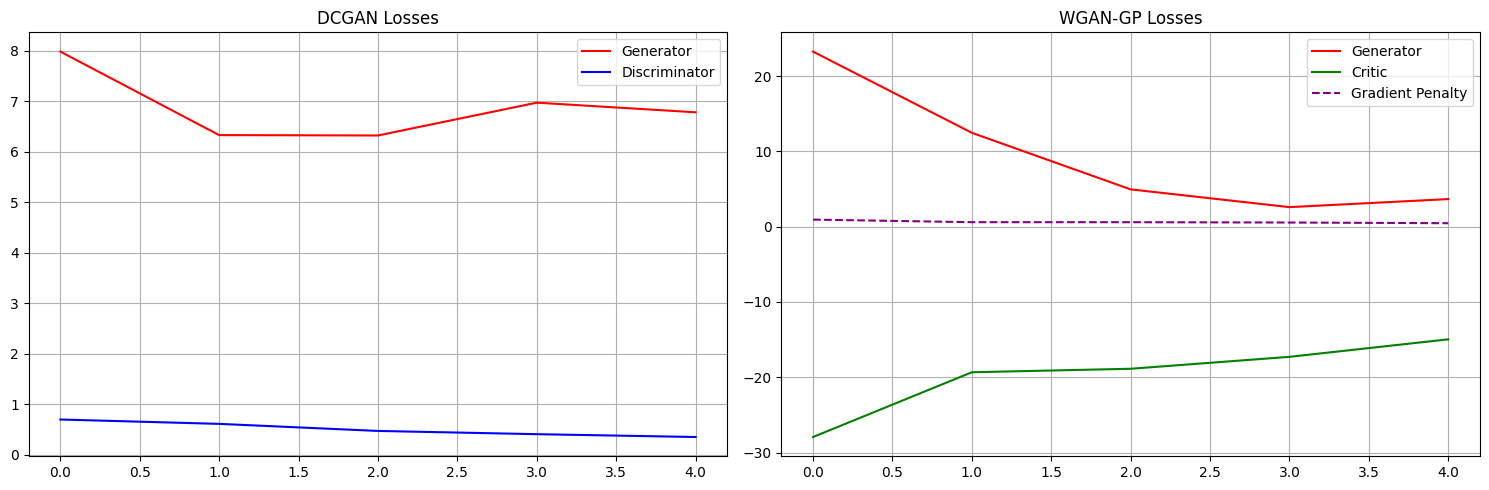

In [32]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,5))
ax1.plot(dcgan_G_losses, label='Generator', color='red')
ax1.plot(dcgan_D_losses, label='Discriminator', color='blue')
ax1.set_title('DCGAN Losses'); ax1.legend(); ax1.grid(True)

ax2.plot(wgan_G_losses, label='Generator', color='red')
ax2.plot(wgan_C_losses, label='Critic', color='green')
ax2.plot(wgan_GP_losses, label='Gradient Penalty', color='purple', linestyle='--')
ax2.set_title('WGAN-GP Losses'); ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.savefig('outputs/loss_curves.png', dpi=150)
plt.show()

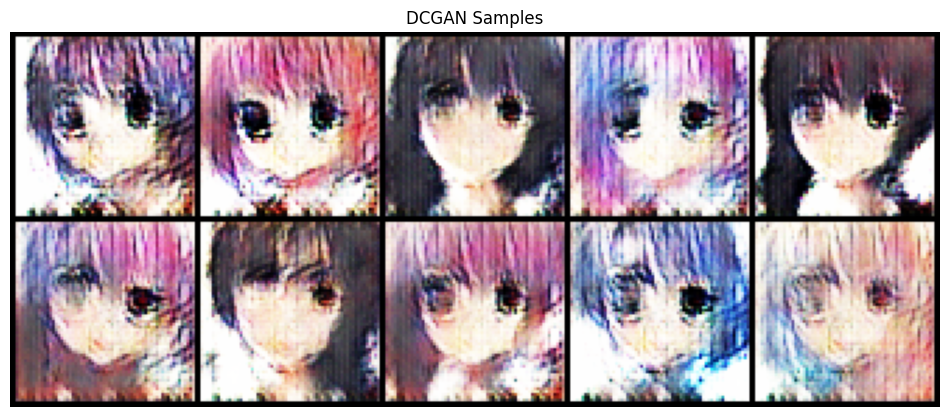

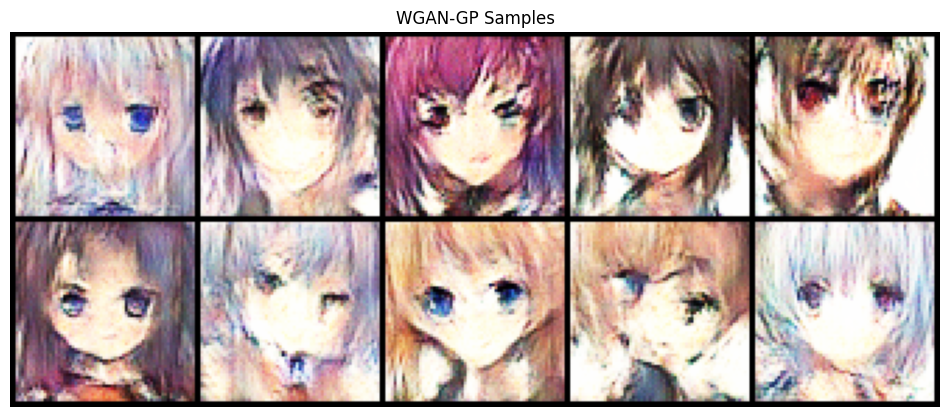

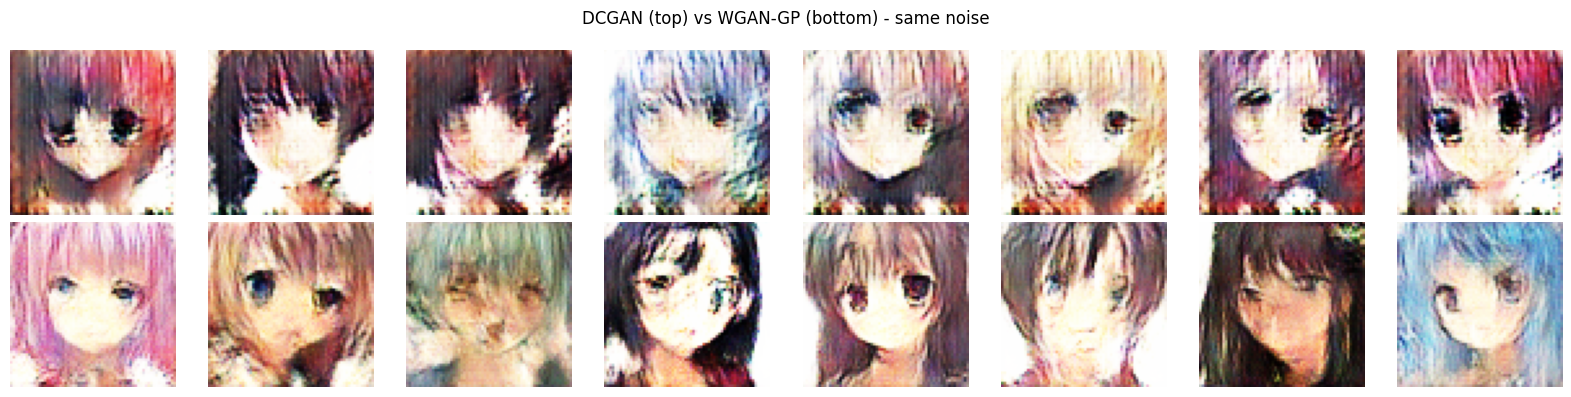

In [34]:
def show_samples(generator, title, n=10):
    generator.eval()
    with torch.no_grad():
        noise = torch.randn(n, NZ, 1, 1, device=device)
        imgs = generator(noise).cpu()
    grid = make_grid(imgs, nrow=5, normalize=True, value_range=(-1,1))
    plt.figure(figsize=(12,6))
    plt.imshow(grid.permute(1,2,0).numpy())
    plt.title(title); plt.axis('off')
    plt.savefig(f"outputs/{title.replace(' ', '_')}.png")
    plt.show()
    generator.train()

show_samples(dcgan_G, "DCGAN Samples")
show_samples(wgan_G, "WGAN-GP Samples")

# Side-by-side same noise
torch.manual_seed(42)
fixed = torch.randn(8, NZ, 1, 1, device=device)
with torch.no_grad():
    d_out = (dcgan_G(fixed).cpu() + 1)/2
    w_out = (wgan_G(fixed).cpu() + 1)/2
fig, axes = plt.subplots(2, 8, figsize=(16,4))
for i in range(8):
    axes[0,i].imshow(d_out[i].permute(1,2,0).numpy()); axes[0,i].axis('off')
    axes[1,i].imshow(w_out[i].permute(1,2,0).numpy()); axes[1,i].axis('off')
plt.suptitle("DCGAN (top) vs WGAN-GP (bottom) - same noise")
plt.tight_layout()
plt.savefig('outputs/comparison.png')
plt.show()

In [35]:
torch.save(dcgan_G.state_dict(), 'outputs/dcgan_final.pth')
torch.save(wgan_G.state_dict(), 'outputs/wgan_final.pth')
with open('outputs/losses.pkl', 'wb') as f:
    pickle.dump({'dcgan_G':dcgan_G_losses, 'dcgan_D':dcgan_D_losses,
                 'wgan_G':wgan_G_losses, 'wgan_C':wgan_C_losses}, f)
print("Models saved.")

Models saved.


In [38]:
# ==================== CELL 11: Professional Gradio App ====================
!pip install gradio -q
import gradio as gr
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from torchvision.utils import make_grid
import io

# ----- Helper functions -----
def generate_images(generator, num_images, seed=None, temperature=1.0):
    """Generate images with optional seed and noise scaling (temperature)."""
    if seed is not None:
        torch.manual_seed(seed)
    noise = torch.randn(num_images, NZ, 1, 1, device=device) * temperature
    with torch.no_grad():
        imgs = (generator(noise).cpu() + 1) / 2  # denormalize to [0,1]
    # Convert to PIL list
    return [Image.fromarray((imgs[i].permute(1,2,0).numpy() * 255).astype('uint8')) for i in range(num_images)]

def generate_comparison(seed, temp):
    """Generate same noise for both models and return side-by-side galleries."""
    if seed is not None:
        torch.manual_seed(int(seed))
    noise = torch.randn(8, NZ, 1, 1, device=device) * temp
    with torch.no_grad():
        dcgan_imgs = (dcgan_G(noise).cpu() + 1) / 2
        wgan_imgs = (wgan_G(noise).cpu() + 1) / 2
    dcgan_pil = [Image.fromarray((dcgan_imgs[i].permute(1,2,0).numpy()*255).astype('uint8')) for i in range(8)]
    wgan_pil = [Image.fromarray((wgan_imgs[i].permute(1,2,0).numpy()*255).astype('uint8')) for i in range(8)]
    return dcgan_pil, wgan_pil

def diversity_grid(generator, model_name, seed=999, temp=1.0):
    """Generate 64 images and return as grid image to spot mode collapse."""
    imgs = generate_images(generator, 64, seed=seed, temperature=temp)
    # Create a grid image using torchvision's make_grid
    tensor_imgs = torch.stack([torch.tensor(np.array(img)/255.0).permute(2,0,1) for img in imgs])
    grid = make_grid(tensor_imgs, nrow=8, padding=2)
    grid_np = (grid.permute(1,2,0).numpy() * 255).astype('uint8')
    return Image.fromarray(grid_np)

def compute_fid_if_possible():
    """Placeholder for FID calculation (optional). Returns a string."""
    # In a real scenario, you would compute FID using a pre-trained InceptionV3
    # For now, return a message that it's optional.
    return "FID score not computed (optional). Run external script for precise FID."

# ----- Custom CSS for professional look -----
custom_css = """
.gradio-container { max-width: 1200px; margin: auto; }
h1 { text-align: center; background: linear-gradient(90deg, #4F46E5, #7C3AED); -webkit-background-clip: text; color: transparent; }
.tab-nav button { font-size: 1.1em; font-weight: 600; }
.generate-btn { background: linear-gradient(90deg, #4F46E5, #7C3AED); border: none; color: white !important; }
.compare-img { border-radius: 12px; box-shadow: 0 10px 15px -3px rgba(0,0,0,0.1); }
"""

# ----- Build App -----
with gr.Blocks(theme=gr.themes.Soft(), css=custom_css) as demo:
    gr.Markdown("""
    #  Generative Adversarial Networks: DCGAN vs WGAN‑GP
    ### Tackling Mode Collapse – Anime Face Generation
    """)
    
    with gr.Tabs():
        # ----- Tab 1: Generate Single Model -----
        with gr.TabItem("✨ Generate Images"):
            with gr.Row():
                with gr.Column(scale=1):
                    model_choice = gr.Radio(["DCGAN", "WGAN-GP"], label="Model", value="WGAN-GP")
                    num_images = gr.Slider(1, 64, value=16, step=1, label="Number of images")
                    seed = gr.Number(value=42, label="Random Seed (optional)", precision=0)
                    temperature = gr.Slider(0.5, 1.5, value=1.0, step=0.05, label="Temperature (noise scale)")
                    btn = gr.Button(" Generate", variant="primary", elem_classes="generate-btn")
                with gr.Column(scale=2):
                    gallery = gr.Gallery(label="Generated Images", columns=4, rows=4, height="auto")
            
            def generate_fn(model, n, s, temp):
                gen = dcgan_G if model == "DCGAN" else wgan_G
                return generate_images(gen, n, seed=int(s) if s else None, temperature=temp)
            
            btn.click(generate_fn, inputs=[model_choice, num_images, seed, temperature], outputs=gallery)
        
        # ----- Tab 2: Side-by-Side Comparison (same noise) -----
        with gr.TabItem(" Compare Models"):
            gr.Markdown("### Same latent vector → different outputs (fixed seed 123 for fair comparison)")
            with gr.Row():
                compare_seed = gr.Number(value=123, label="Fixed Seed", precision=0, interactive=True)
                compare_temp = gr.Slider(0.5, 1.5, value=1.0, step=0.05, label="Temperature")
                compare_btn = gr.Button(" Compare", variant="primary")
            with gr.Row():
                with gr.Column():
                    gr.Markdown("#### DCGAN")
                    dcgan_gallery = gr.Gallery(label="DCGAN Outputs", columns=4, rows=2, height="auto")
                with gr.Column():
                    gr.Markdown("#### WGAN-GP")
                    wgan_gallery = gr.Gallery(label="WGAN-GP Outputs", columns=4, rows=2, height="auto")
            
            compare_btn.click(generate_comparison, inputs=[compare_seed, compare_temp], outputs=[dcgan_gallery, wgan_gallery])
        
        # ----- Tab 3: Diversity Analysis (Mode Collapse Detection) -----
        with gr.TabItem(" Diversity Analysis"):
            gr.Markdown("### Generate 64 images – check for mode collapse (repetition)")
            with gr.Row():
                with gr.Column():
                    gr.Markdown("#### DCGAN (may show mode collapse)")
                    dcgan_div_btn = gr.Button("🎲 Generate 64 DCGAN")
                    dcgan_div_out = gr.Image(label="DCGAN 64-grid", type="pil")
                with gr.Column():
                    gr.Markdown("#### WGAN-GP (should be more diverse)")
                    wgan_div_btn = gr.Button("🎲 Generate 64 WGAN-GP")
                    wgan_div_out = gr.Image(label="WGAN-GP 64-grid", type="pil")
            
            dcgan_div_btn.click(lambda: diversity_grid(dcgan_G, "DCGAN"), outputs=dcgan_div_out)
            wgan_div_btn.click(lambda: diversity_grid(wgan_G, "WGAN-GP"), outputs=wgan_div_out)
            gr.Markdown("**Interpretation:** If DCGAN images look similar (same face repeated), mode collapse is present. WGAN-GP should show more variation.")
        
        # ----- Tab 4: Training Metrics & Optional FID -----
        with gr.TabItem("Training Metrics"):
            # Loss curves
            if os.path.exists('outputs/loss_curves.png'):
                gr.Image('outputs/loss_curves.png', label="Training Loss Curves (DCGAN vs WGAN-GP)")
            else:
                gr.Markdown(" Loss curves not found. Run training cells first to generate `outputs/loss_curves.png`.")
            # FID Score (optional)
            gr.Markdown("### Frechet Inception Distance (Optional)")
            fid_btn = gr.Button("Compute FID (approx)", variant="secondary")
            fid_output = gr.Textbox(label="FID Score", placeholder="Click to compute (requires InceptionV3)")
            fid_btn.click(compute_fid_if_possible, outputs=fid_output)
            
    
   

# Launch
demo.launch(share=True, debug=False)

/tmp/ipykernel_55/4023696074.py:59: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft(), css=custom_css) as demo:
/tmp/ipykernel_55/4023696074.py:59: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft(), css=custom_css) as demo:


* Running on local URL:  http://127.0.0.1:7862
* Running on public URL: https://a2aa16b9b2232fc631.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
